In [1]:
import multiprocessing
import os
import re
from concurrent.futures import ProcessPoolExecutor, as_completed
import gc
import pandas as pd
import matplotlib.pyplot as plt
from pyulog import ULog

In [2]:
# return the array of combined log file line
def getLogData(baseLogDir, iteration, testCase, model="iris"):
    logPath = os.path.join(baseLogDir, iteration, model, testCase, "log-combined.log_plain.log")
    log = None

    if os.path.exists(logPath):
        with open(logPath, "r") as f:
            log = f.readlines()

    return log

In [3]:
# return the ulg file name parsed from the combined log
def findUlgName(log):
    pattern = r"INFO\s+\[logger\]\s+Opened full log file:\s+(.*\.ulg)"
    ulg_file_name = ""

    match = re.search(pattern, log)

    if match:
        ulg_file_name = match.group(1)

    return ulg_file_name

In [4]:
# return the ulog parsed from the ulg file
def getUlogData(baseUlgDir, ulgFileName):
    ulog = None

    normPath = os.path.normpath(ulgFileName)
    ulgPath = os.path.join(baseUlgDir, normPath)

    if os.path.exists(ulgPath):
        ulog = ULog(ulgPath)

    return ulog

In [5]:
# 병렬 처리를 위한 작업 함수
def process_test_case(args):
    baseLogDir, baseUlgDir, testIteration, model, testCase = args

    try:
        # 로그 데이터 가져오기
        combinedLog = getLogData(baseLogDir, testIteration, testCase, model)

        # ULG 파일명 찾기
        ulgFileName = findUlgName("".join(combinedLog) if combinedLog else "")

        # ULog 데이터 가져오기
        ulog = getUlogData(baseUlgDir, ulgFileName)
        '''
        vehicle_angular_velocity_groundtruth = pd.DataFrame(ulog.get_dataset("vehicle_angular_velocity_groundtruth").data)
        vehicle_attitude_groundtruth = pd.DataFrame(ulog.get_dataset("vehicle_attitude_groundtruth").data)
        vehicle_local_position_groundtruth = pd.DataFrame(ulog.get_dataset("vehicle_local_position_groundtruth").data)
        vehicle_global_position_groundtruth = pd.DataFrame(ulog.get_dataset("vehicle_global_position_groundtruth").data)'''
        estimator_sensor_bias = pd.DataFrame(ulog.get_dataset("estimator_sensor_bias").data)

        del ulog
        gc.collect()

        # 결과 반환: (키, 데이터) 형태
        return (testIteration, testCase, {
            "combinedLog": combinedLog,
            "ulog": {
                '''
                "vehicle_angular_velocity_groundtruth": vehicle_angular_velocity_groundtruth,
                "vehicle_attitude_groundtruth": vehicle_attitude_groundtruth,
                "vehicle_local_position_groundtruth": vehicle_local_position_groundtruth,
                "vehicle_global_position_groundtruth": vehicle_global_position_groundtruth,'''
                "estimator_sensor_bias": estimator_sensor_bias
            }
        })
    except Exception as e:
        print(f"Error processing {testIteration}/{model}/{testCase}: {e}")
        return (testIteration, testCase, {
            "combinedLog": None,
            "ulog": None,
            "error": str(e)
        })

In [6]:
# 메인 코드
def load_flight_data_parallel(baseLogDir, baseUlgDir, max_workers=None):
    # 기본 worker 수를 CPU 코어 수의 절반으로 설정
    if max_workers is None:
        max_workers = max(1, multiprocessing.cpu_count()//2)

    flightData = {}
    tasks = []

    # 모든 작업을 준비
    for testIteration in os.listdir(baseLogDir):
        flightData[testIteration] = {}
        iterationDir = os.path.join(baseLogDir, testIteration)

        for model_name in os.listdir(iterationDir):
            modelDir = os.path.join(iterationDir, model_name)

            for testCase in os.listdir(modelDir):
                # 작업 추가
                tasks.append((baseLogDir, baseUlgDir, testIteration, model_name, testCase))

    # 진행 상황 추적용 변수
    total_tasks = len(tasks)
    completed_tasks = 0

    # 병렬 실행
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # 작업 제출
        future_to_task = {executor.submit(process_test_case, task): task for task in tasks}

        # 결과 수집
        for future in as_completed(future_to_task):
            try:
                testIteration, testCase, result = future.result()

                # 결과를 flightData에 저장
                if testIteration not in flightData:
                    flightData[testIteration] = {}

                flightData[testIteration][testCase] = result

                # 진행 상황 업데이트
                completed_tasks += 1
                if completed_tasks % 10 == 0 or completed_tasks == total_tasks:
                    print(f"Progress: {completed_tasks}/{total_tasks} ({completed_tasks / total_tasks * 100:.1f}%)")

            except Exception as e:
                task = future_to_task[future]
                print(f"Exception processing task {task}: {e}")

    return flightData

In [7]:
# ulg, combined log 기본 위치
baseLogDir = os.path.expanduser("~/PX4-Autopilot/logs/2025-03-21T21-42-37Z")
baseUlgDir = os.path.expanduser("~/PX4-Autopilot/build/px4_sitl_default/tmp_mavsdk_tests/rootfs")

# 병렬 처리를 통한 데이터 로딩
flightData = load_flight_data_parallel(baseLogDir, baseUlgDir)

# 결과 확인
print("Data loading completed.")
for iteration in flightData:
    print(f"Iteration: {iteration}, Test cases: {len(flightData[iteration])}")

Progress: 10/4400 (0.2%)
Progress: 20/4400 (0.5%)
Progress: 30/4400 (0.7%)
Progress: 40/4400 (0.9%)
Progress: 50/4400 (1.1%)
Progress: 60/4400 (1.4%)
Progress: 70/4400 (1.6%)
Progress: 80/4400 (1.8%)
Progress: 90/4400 (2.0%)
Progress: 100/4400 (2.3%)
Progress: 110/4400 (2.5%)
Progress: 120/4400 (2.7%)
Progress: 130/4400 (3.0%)
Progress: 140/4400 (3.2%)
Progress: 150/4400 (3.4%)
Progress: 160/4400 (3.6%)
Progress: 170/4400 (3.9%)
Progress: 180/4400 (4.1%)
Progress: 190/4400 (4.3%)
Progress: 200/4400 (4.5%)
Progress: 210/4400 (4.8%)
Progress: 220/4400 (5.0%)
Progress: 230/4400 (5.2%)
Progress: 240/4400 (5.5%)
Progress: 250/4400 (5.7%)
Progress: 260/4400 (5.9%)
Progress: 270/4400 (6.1%)
Progress: 280/4400 (6.4%)
Progress: 290/4400 (6.6%)
Progress: 300/4400 (6.8%)
Progress: 310/4400 (7.0%)
Progress: 320/4400 (7.3%)
Progress: 330/4400 (7.5%)
Progress: 340/4400 (7.7%)
Progress: 350/4400 (8.0%)
Progress: 360/4400 (8.2%)
Progress: 370/4400 (8.4%)
Progress: 380/4400 (8.6%)
Progress: 390/4400 (8


KeyboardInterrupt



In [9]:
print(flightData.keys())

NameError: name 'flightData' is not defined

In [48]:
df = flightData["002"]["normal_mission_straight_20.f"]["ulog"]["estimator_sensor_bias"]

KeyError: '002'

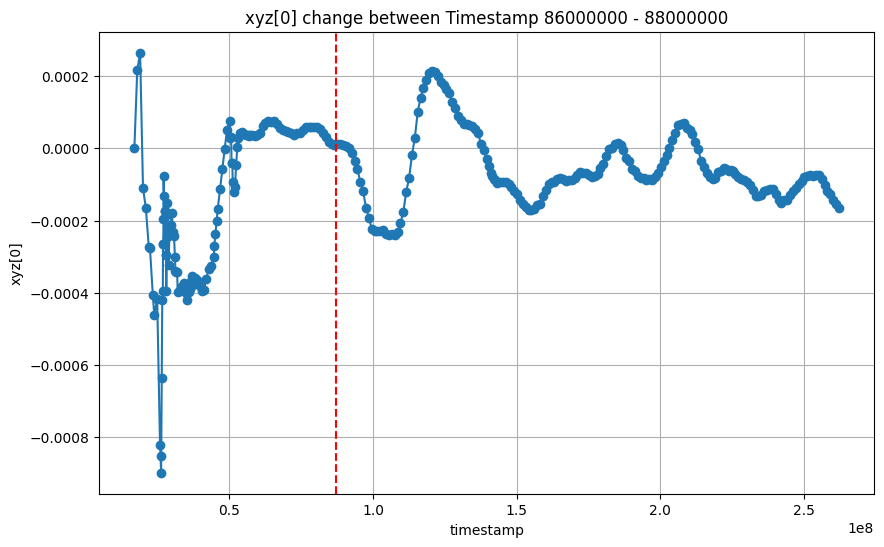

In [49]:
#filtered_df = df[(df['timestamp'] >= 86000000) & (df['timestamp'] <= 88000000)]
filtered_df = df

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['timestamp'], filtered_df['gyro_bias[0]'], marker='o', linestyle='-')
plt.xlabel('timestamp')
plt.ylabel('xyz[0]')
plt.title('xyz[0] change between Timestamp 86000000 - 88000000')
plt.grid(True)

plt.axvline(x=87104000, color='red', linestyle='--', label='87104000')

plt.show()

In [50]:
df = df["gyro_bias[0]"]
print("max: ", df.max())
print()
print("min", df.min())

max:  0.00026477536

min -0.0008978475
